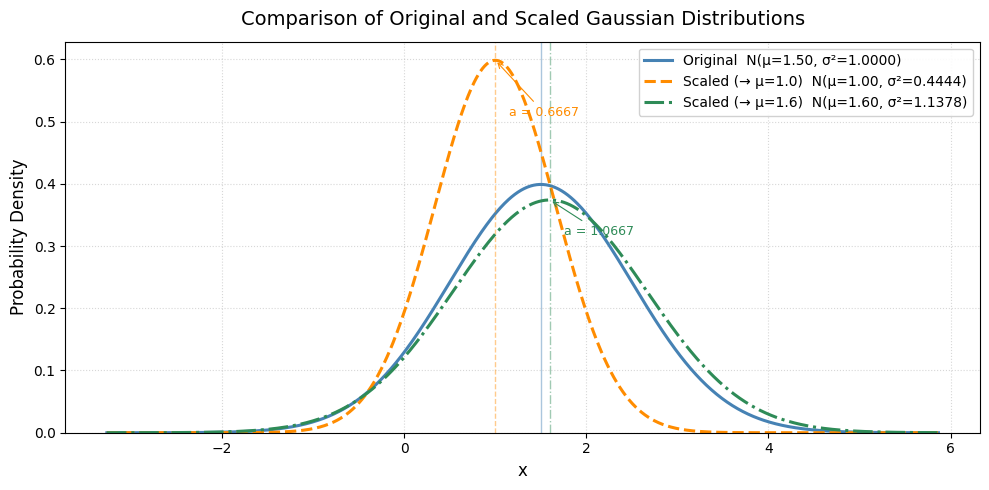

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ─── 파라미터 설정 ─────────────────────────────────────────
# 원본 분포: N(1.5, 1) — mean=1.5, variance=1 (std=1)
MEAN_ORIG = 1.5
VAR_ORIG  = 1.0
STD_ORIG  = np.sqrt(VAR_ORIG)

# 스케일링 대상 평균들
# 스케일링 원리: X ~ N(μ, σ²) → aX ~ N(aμ, (aσ)²)
# 스케일 인수 a = target_mean / mean_orig
TARGETS = [
    {"target_mean": 1.5, "color": "steelblue",   "ls": "-",  "label": "Original"},
    {"target_mean": 1.0, "color": "darkorange",   "ls": "--", "label": "Scaled (→ μ=1.0)"},
    {"target_mean": 1.6, "color": "seagreen",     "ls": "-.", "label": "Scaled (→ μ=1.6)"},
]

# ─── 분포 파라미터 계산 ────────────────────────────────────
dists = []
for t in TARGETS:
    a    = t["target_mean"] / MEAN_ORIG   # 스케일 인수
    mean = a * MEAN_ORIG                  # = target_mean
    std  = a * STD_ORIG                   # 표준편차도 같은 비율로 스케일
    var  = std ** 2
    dists.append({**t, "a": a, "mean": mean, "std": std, "var": var})

# ─── x 범위: 가장 넓은 분포 기준으로 동적 설정 ────────────
max_std = max(d["std"] for d in dists)
all_means = [d["mean"] for d in dists]
x = np.linspace(min(all_means) - 4 * max_std,
                max(all_means) + 4 * max_std, 800)

# ─── 플롯 ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for d in dists:
    pdf = norm.pdf(x, loc=d["mean"], scale=d["std"])
    ax.plot(x, pdf,
            color=d["color"], linestyle=d["ls"], linewidth=2.2,
            label=f'{d["label"]}  N(μ={d["mean"]:.2f}, σ²={d["var"]:.4f})')
    ax.axvline(d["mean"], color=d["color"], linestyle=d["ls"],
                linewidth=1.0, alpha=0.45)

# ─── 스케일링 정보 주석 ────────────────────────────────────
for d in dists[1:]:   # 스케일된 분포만 주석
    ax.annotate(
        f'a = {d["a"]:.4f}',
        xy=(d["mean"], norm.pdf(d["mean"], d["mean"], d["std"])),
        xytext=(d["mean"] + 0.15, norm.pdf(d["mean"], d["mean"], d["std"]) * 0.85),
        fontsize=9, color=d["color"],
        arrowprops=dict(arrowstyle="->", color=d["color"], lw=0.8),
    )

# ─── 스타일 ────────────────────────────────────────────────
ax.set_title("Comparison of Original and Scaled Gaussian Distributions",
            fontsize=14, pad=12)
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)
ax.legend(loc="upper right", fontsize=10, framealpha=0.9)
ax.grid(True, linestyle=":", alpha=0.5)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()